Install & Imports

In [1]:
!pip install -q kagglehub tensorflow opencv-python matplotlib seaborn scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam


Download Dataset

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("fernando2rad/x-ray-lung-diseases-images-9-classes")
print("Downloaded to:", dataset_path)

100%|██████████| 182M/182M [00:01<00:00, 130MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/fernando2rad/x-ray-lung-diseases-images-9-classes/versions/1


Fix Dataset Path

In [3]:
def find_dataset_root(path):
    for root, dirs, files in os.walk(path):
        if len(dirs) > 2:
            return root
    return path

DATASET_PATH = find_dataset_root(dataset_path)

print("Final path:", DATASET_PATH)
print("Classes:", os.listdir(DATASET_PATH))

Final path: /root/.cache/kagglehub/datasets/fernando2rad/x-ray-lung-diseases-images-9-classes/versions/1
Classes: ['01 Processos Inflamatórios Pulmonares (Pneumonia)', '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)', '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)', '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)', '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)', '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)', '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)', '00 Anatomia Normal', '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)']


Build DataFrame

In [4]:
def build_dataframe(data_dir):
    filepaths = []
    labels = []

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img in os.listdir(class_path):
                filepaths.append(os.path.join(class_path, img))
                labels.append(class_name)

    return pd.DataFrame({"filepath": filepaths, "label": labels})

df = build_dataframe(DATASET_PATH)
print("Total images:", len(df))
df.head()

Total images: 6743


,filepath,label
0,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
1,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
2,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
3,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)
4,/root/.cache/kagglehub/datasets/fernando2rad/x...,01 Processos Inflamatórios Pulmonares (Pneumonia)


Data Preprocessing

In [5]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()
df = df[df['filepath'].apply(os.path.exists)]

print("After cleaning:", len(df))

Missing values:
 filepath    0
label       0
dtype: int64
Duplicates: 0
After cleaning: 6743


EDA (Distribution)

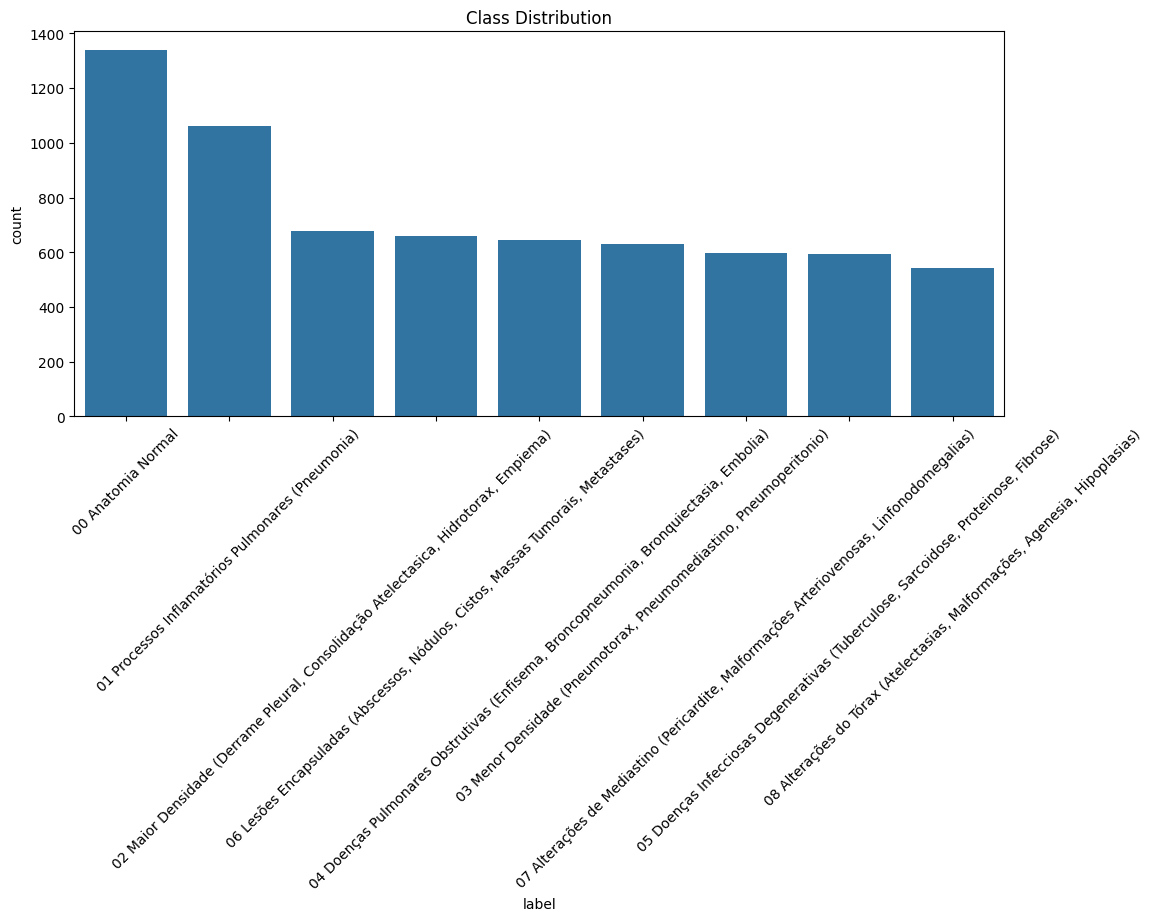

In [6]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="label", order=df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

EDA (Sample Images)

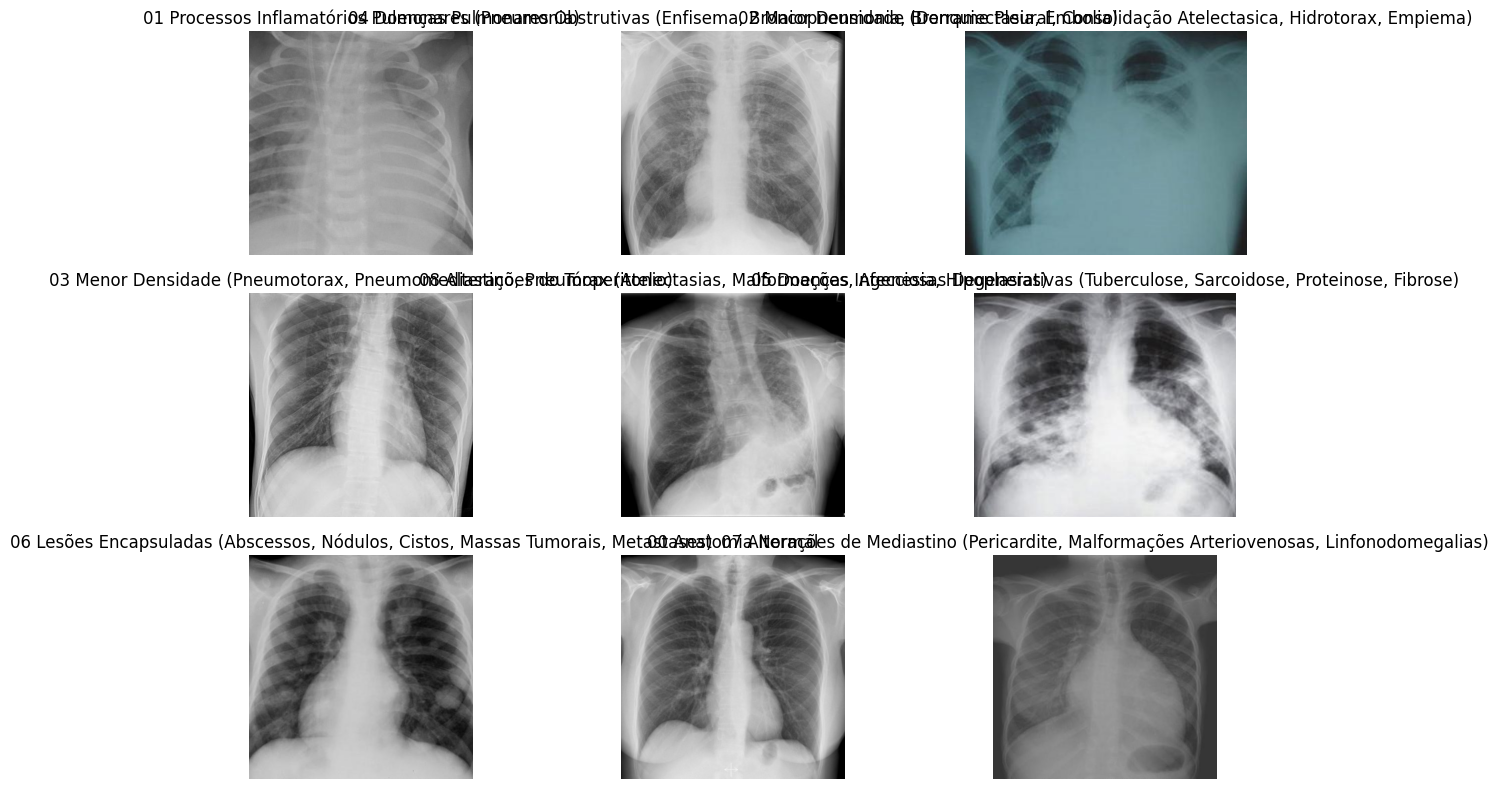

In [7]:
plt.figure(figsize=(12,8))

for i, label in enumerate(df['label'].unique()[:9]):
    img_path = random.choice(df[df['label']==label]['filepath'].values)
    img = cv2.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

Split Data

In [8]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

Parameters

In [9]:
IMG_SIZE = 299
BATCH_SIZE = 32
EPOCHS = 20


Feature Engineering (Augmentation)

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=inception_preprocess,
    rotation_range=15,       # زود من 10
    zoom_range=0.15,         # زود من 0.1
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],  # زود النطاق
    shear_range=0.1,         # ← جديد
    width_shift_range=0.1,   # ← جديد
    height_shift_range=0.1   # ← جديد
)
eval_datagen = ImageDataGenerator(
    preprocessing_function=inception_preprocess
)


Generators

In [11]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE
)

val_gen = eval_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = eval_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4720 validated image filenames belonging to 9 classes.
Found 1011 validated image filenames belonging to 9 classes.
Found 1012 validated image filenames belonging to 9 classes.


Class Weights

In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

class_weight_dict = dict(enumerate(class_weights))

# زوّد وزن class 01 (Pneumonia) بشكل صريح
pneumonia_class_name = [c for c in train_gen.class_indices.keys() if c.startswith("01 ")][0]
pneumonia_idx = train_gen.class_indices[pneumonia_class_name]

class_weight_dict[pneumonia_idx] *= 1.5

print("Pneumonia class:", pneumonia_class_name)
print("Pneumonia index:", pneumonia_idx)
print("Class weights:", class_weight_dict)

Pneumonia class: 01 Processos Inflamatórios Pulmonares (Pneumonia)
Pneumonia index: 1
Class weights: {0: np.float64(0.5591092158256338), 1: np.float64(1.060197663971249), 2: np.float64(1.1064228785747774), 3: np.float64(1.1919191919191918), 4: np.float64(1.1628479921162849), 5: np.float64(1.2606837606837606), 6: np.float64(1.1376235237406604), 7: np.float64(1.2576605382360777), 8: np.float64(1.3764946048410616)}


In [13]:
print(train_gen.class_indices)
print(len(train_gen.class_indices))

{'00 Anatomia Normal': 0, '01 Processos Inflamatórios Pulmonares (Pneumonia)': 1, '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)': 2, '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)': 3, '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)': 4, '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)': 5, '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)': 6, '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)': 7, '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)': 8}
9


Build Model

In [14]:
def build_model(num_classes):
    base_model = InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs=base_model.input, outputs=outputs)

num_classes = len(train_gen.class_indices)

model = build_model(num_classes)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 22,337,833 (85.21 MB)

 Trainable params: 530,953 (2.03 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

early stopping

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_inceptionv3_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


Training

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight_dict
)

Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.2515 - loss: 2.8089
Epoch 1: val_accuracy improved from None to 0.58160, saving model to best_inceptionv3_model.h5



Epoch 1: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.3644 - loss: 2.2595 - val_accuracy: 0.5816 - val_loss: 1.3051
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.5420 - loss: 1.5122
Epoch 2: val_accuracy improved from 0.58160 to 0.73986, saving model to best_inceptionv3_model.h5



Epoch 2: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 140s 944ms/step - accuracy: 0.5676 - loss: 1.4238 - val_accuracy: 0.7399 - val_loss: 0.8907
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.6455 - loss: 1.1489
Epoch 3: val_accuracy improved from 0.73986 to 0.77448, saving model to best_inceptionv3_model.h5



Epoch 3: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 139s 937ms/step - accuracy: 0.6498 - loss: 1.1243 - val_accuracy: 0.7745 - val_loss: 0.7173
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.6820 - loss: 1.0006
Epoch 4: val_accuracy improved from 0.77448 to 0.80613, saving model to best_inceptionv3_model.h5



Epoch 4: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 138s 926ms/step - accuracy: 0.6941 - loss: 0.9702 - val_accuracy: 0.8061 - val_loss: 0.6229
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 916ms/step - accuracy: 0.7126 - loss: 0.9059
Epoch 5: val_accuracy improved from 0.80613 to 0.81503, saving model to best_inceptionv3_model.h5


...


Epoch 24: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 142s 960ms/step - accuracy: 0.8862 - loss: 0.3354 - val_accuracy: 0.9308 - val_loss: 0.2257
Epoch 25/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.8816 - loss: 0.3462
Epoch 25: val_accuracy improved from 0.93076 to 0.93373, saving model to best_inceptionv3_model.h5



Epoch 25: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 141s 956ms/step - accuracy: 0.8867 - loss: 0.3397 - val_accuracy: 0.9337 - val_loss: 0.2159
Epoch 26/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.8982 - loss: 0.3084
Epoch 26: val_accuracy did not improve from 0.93373
148/148 ━━━━━━━━━━━━━━━━━━━━ 145s 980ms/step - accuracy: 0.8947 - loss: 0.3150 - val_accuracy: 0.9337 - val_loss: 0.2170
Epoch 27/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.8880 - loss: 0.3242
Epoch 27: val_accuracy improved from 0.93373 to 0.93670, saving model to best_inceptionv3_model.h5



Epoch 27: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 140s 949ms/step - accuracy: 0.8960 - loss: 0.3132 - val_accuracy: 0.9367 - val_loss: 0.2049
Epoch 28/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.8935 - loss: 0.3164
Epoch 28: val_accuracy improved from 0.93670 to 0.93867, saving model to best_inceptionv3_model.h5



Epoch 28: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 141s 953ms/step - accuracy: 0.8924 - loss: 0.3154 - val_accuracy: 0.9387 - val_loss: 0.1983
Epoch 29/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.8991 - loss: 0.3051
Epoch 29: val_accuracy did not improve from 0.93867
148/148 ━━━━━━━━━━━━━━━━━━━━ 140s 945ms/step - accuracy: 0.8998 - loss: 0.3036 - val_accuracy: 0.9387 - val_loss: 0.1898
Epoch 30/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - accuracy: 0.9043 - loss: 0.2789
Epoch 30: val_accuracy improved from 0.93867 to 0.94065, saving model to best_inceptionv3_model.h5



Epoch 30: finished saving model to best_inceptionv3_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 138s 935ms/step - accuracy: 0.9021 - loss: 0.2953 - val_accuracy: 0.9407 - val_loss: 0.1922


Fine-Tuning

In [17]:
import tensorflow as tf
for layer in model.layers:
    layer.trainable = False
for layer in model.layers[-5:]:
    layer.trainable = True
for layer in model.layers[-35:-5]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

print("Trainable layers:", sum(layer.trainable for layer in model.layers))
print("Total layers:", len(model.layers))

Trainable layers: 26
Total layers: 316


In [18]:
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy()

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

In [19]:
fine_checkpoint = ModelCheckpoint(
    'best_inceptionv3_model_finetuned.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, fine_checkpoint],
    class_weight=class_weight_dict
)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.9081 - loss: 0.0363
Epoch 1: val_accuracy improved from None to 0.94955, saving model to best_inceptionv3_model_finetuned.h5



Epoch 1: finished saving model to best_inceptionv3_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9017 - loss: 0.0398 - val_accuracy: 0.9496 - val_loss: 0.0219
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.9073 - loss: 0.0344
Epoch 2: val_accuracy improved from 0.94955 to 0.95153, saving model to best_inceptionv3_model_finetuned.h5



Epoch 2: finished saving model to best_inceptionv3_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 143s 968ms/step - accuracy: 0.9061 - loss: 0.0358 - val_accuracy: 0.9515 - val_loss: 0.0225
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.8970 - loss: 0.0396
Epoch 3: val_accuracy did not improve from 0.95153
148/148 ━━━━━━━━━━━━━━━━━━━━ 143s 959ms/step - accuracy: 0.9019 - loss: 0.0379 - val_accuracy: 0.9446 - val_loss: 0.0243
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.9095 - loss: 0.0319
Epoch 4: val_accuracy improved from 0.95153 to 0.95252, saving model to best_inceptionv3_model_finetuned.h5



Epoch 4: finished saving model to best_inceptionv3_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 144s 968ms/step - accuracy: 0.9114 - loss: 0.0321 - val_accuracy: 0.9525 - val_loss: 0.0200
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.9077 - loss: 0.0347
Epoch 5: val_accuracy did not improve from 0.95252
148/148 ━━━━━━━━━━━━━━━━━━━━ 142s 957ms/step - accuracy: 0.9148 - loss: 0.0315 - val_accuracy: 0.9515 - val_loss: 0.0198
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.9077 - loss: 0.0315
Epoch 6: val_accuracy improved from 0.95252 to 0.95549, saving model to best_inceptionv3_model_finetuned.h5



Epoch 6: finished saving model to best_inceptionv3_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 141s 954ms/step - accuracy: 0.9155 - loss: 0.0290 - val_accuracy: 0.9555 - val_loss: 0.0179
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.9256 - loss: 0.0310
Epoch 7: val_accuracy improved from 0.95549 to 0.95747, saving model to best_inceptionv3_model_finetuned.h5



Epoch 7: finished saving model to best_inceptionv3_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 143s 960ms/step - accuracy: 0.9208 - loss: 0.0307 - val_accuracy: 0.9575 - val_loss: 0.0194
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.9212 - loss: 0.0268
Epoch 8: val_accuracy did not improve from 0.95747
148/148 ━━━━━━━━━━━━━━━━━━━━ 143s 963ms/step - accuracy: 0.9191 - loss: 0.0286 - val_accuracy: 0.9525 - val_loss: 0.0171
Epoch 9/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.9199 - loss: 0.0292
Epoch 9: val_accuracy improved from 0.95747 to 0.95945, saving model to best_inceptionv3_model_finetuned.h5



Epoch 9: finished saving model to best_inceptionv3_model_finetuned.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 140s 947ms/step - accuracy: 0.9203 - loss: 0.0278 - val_accuracy: 0.9594 - val_loss: 0.0168
Epoch 10/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 927ms/step - accuracy: 0.9240 - loss: 0.0270
Epoch 10: val_accuracy did not improve from 0.95945
148/148 ━━━━━━━━━━━━━━━━━━━━ 144s 963ms/step - accuracy: 0.9282 - loss: 0.0260 - val_accuracy: 0.9476 - val_loss: 0.0187


Evaluation

In [20]:
loss, acc = model.evaluate(test_gen)
print("InceptionV3 Test Accuracy:", acc)


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 479ms/step - accuracy: 0.9704 - loss: 0.0117
InceptionV3 Test Accuracy: 0.970355749130249


Accuracy Curve

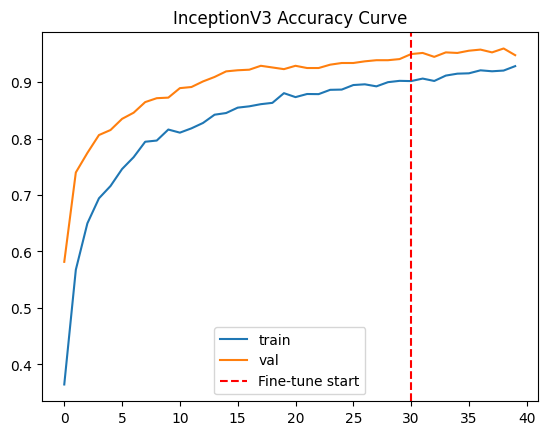

In [21]:
all_acc = history.history['accuracy'] + history_fine.history['accuracy']
all_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']


plt.plot(all_acc, label='train')
plt.plot(all_val_acc, label='val')
plt.axvline(x=len(history.history['accuracy']), color='red', linestyle='--', label='Fine-tune start')
plt.legend()
plt.title("InceptionV3 Accuracy Curve")
plt.show()


Confusion Matrix

32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 419ms/step


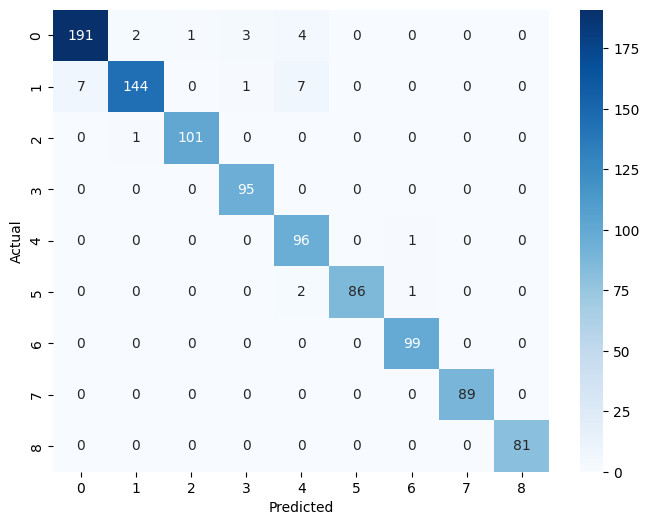

In [22]:
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal       0.96      0.95      0.96       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)       0.98      0.91      0.94       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)       0.99      0.99      0.99       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)       0.96      1.00      0.98        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)       0.88      0.99      0.93        97
      05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)       1.00      0.97      0.98        89
         06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Meta

Predict Image

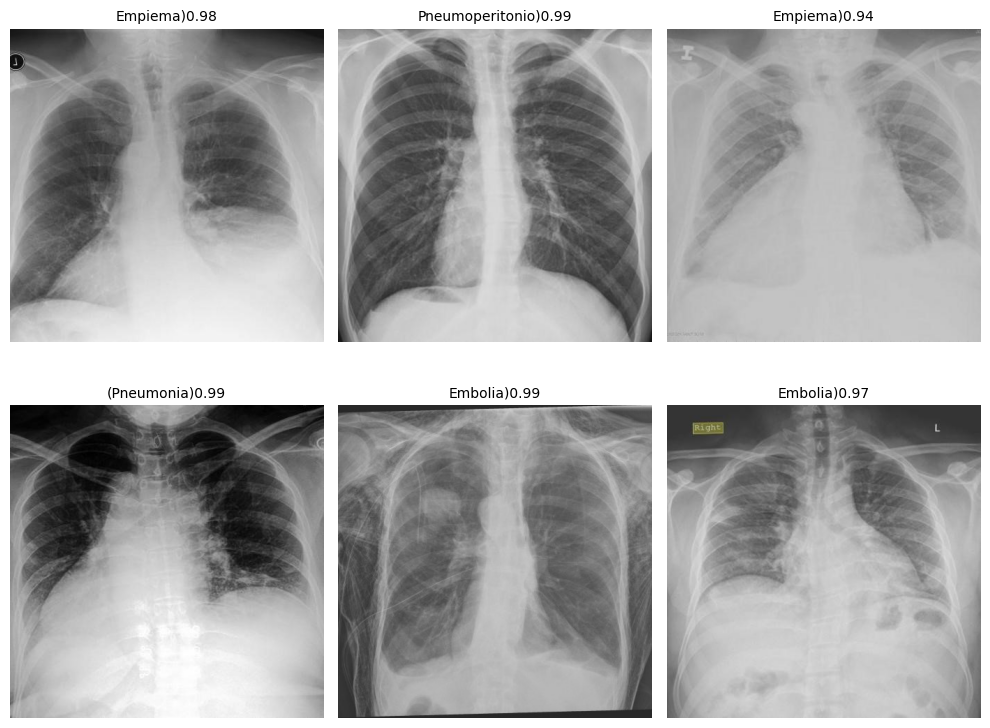

In [25]:
def predict_image(img_path):
    if not os.path.exists(img_path):
        return None, None

    img = cv2.imread(img_path)
    if img is None:
        return None, None

    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = inception_preprocess(img)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)
    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    class_name = list(train_gen.class_indices.keys())[class_idx]

    short_name = class_name.split(' ')[-1]

    return img_display, f"{short_name}{confidence:.2f}"


paths = test_df['filepath'].sample(6).values

plt.figure(figsize=(10, 8))

for i, p in enumerate(paths):
    img, title = predict_image(p)
    if img is None:
        continue

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(title, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


Install + imports for LIME / SHAP

In [26]:
!pip install -q lime shap scikit-image

import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [27]:

class_names = list(train_gen.class_indices.keys())

def load_rgb_image(img_path, size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.uint8)

def preprocess_for_model(images):
    images = np.array(images).astype(np.float32)
    return inception_preprocess(images.copy())

def predict_for_xai(images):
    images = preprocess_for_model(images)
    return model.predict(images, verbose=0)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

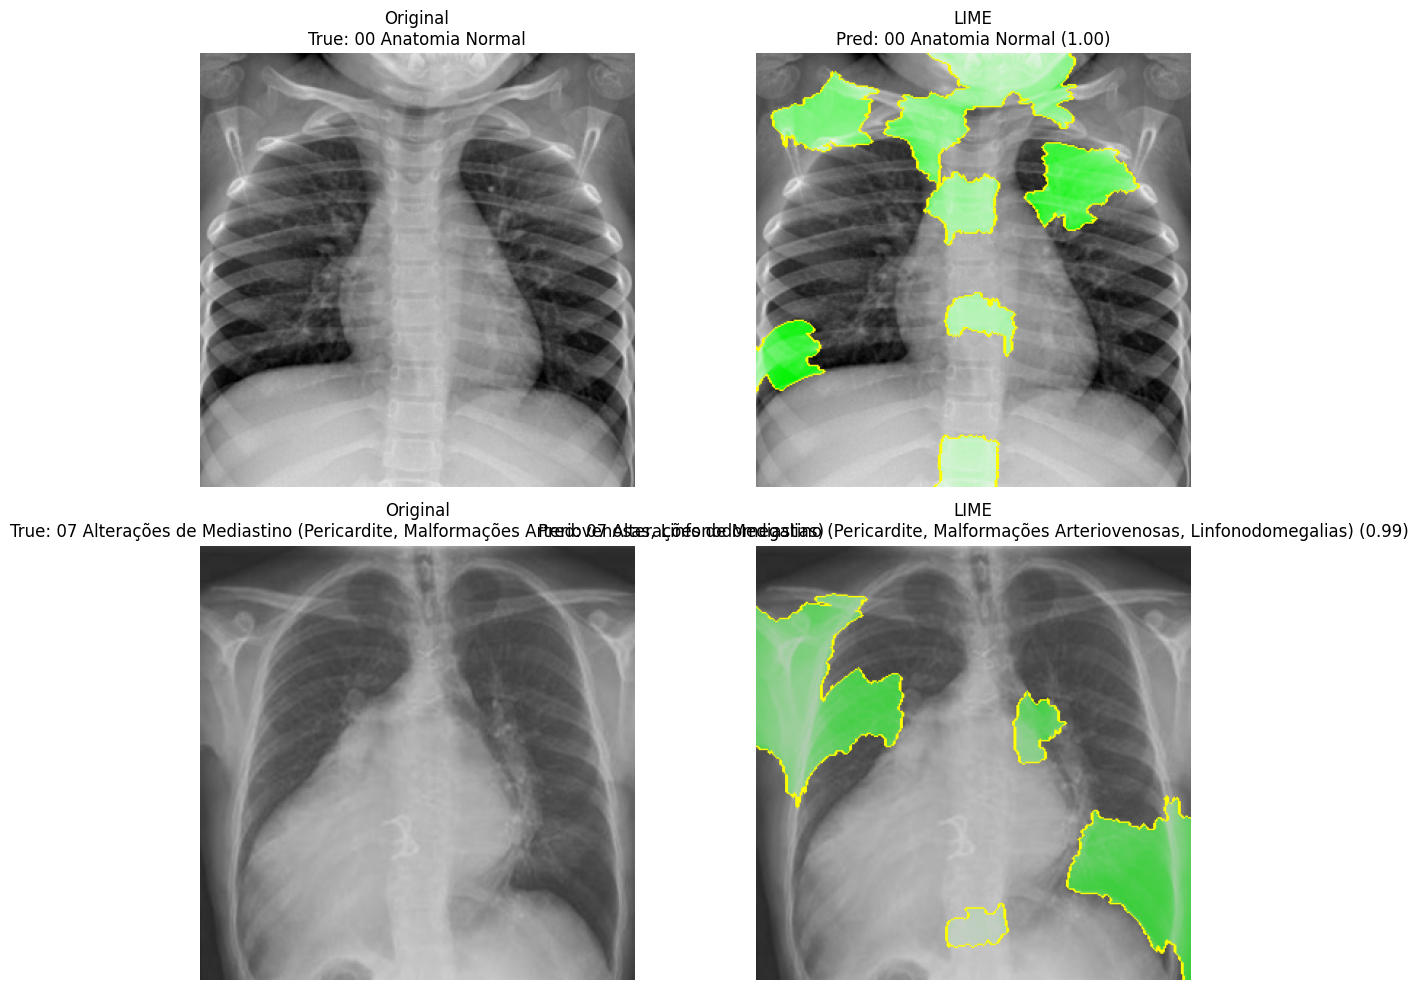

In [28]:
# LIME on 2 random test images

lime_explainer = lime_image.LimeImageExplainer()

sample_rows = test_df.sample(2, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i, row in sample_rows.iterrows():
    img_path = row["filepath"]
    true_label = row["label"]

    img = load_rgb_image(img_path)

    preds = predict_for_xai(np.expand_dims(img, axis=0))
    pred_idx = int(np.argmax(preds[0]))
    pred_label = class_names[pred_idx]
    confidence = float(preds[0][pred_idx])

    explanation = lime_explainer.explain_instance(
        image=img,
        classifier_fn=predict_for_xai,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    lime_img, lime_mask = explanation.get_image_and_mask(
        label=pred_idx,
        positive_only=False,
        num_features=8,
        hide_rest=False
    )

    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(mark_boundaries(lime_img / 255.0, lime_mask))
    plt.title(f"LIME\nPred: {pred_label} ({confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:47, 23.59s/it]


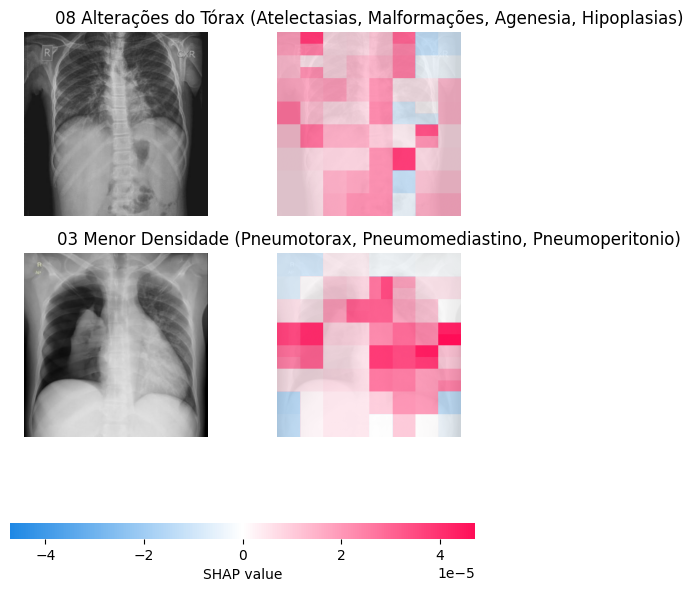

In [29]:
shap_masker = shap.maskers.Image("blur(32,32)", (IMG_SIZE, IMG_SIZE, 3))
shap_explainer = shap.Explainer(
    predict_for_xai,
    shap_masker,
    output_names=class_names
)

shap_rows = test_df.sample(2, random_state=7).reset_index(drop=True)
shap_images = np.array([load_rgb_image(p) for p in shap_rows["filepath"]])

shap_values = shap_explainer(
    shap_images,
    max_evals=300,
    batch_size=16,
    outputs=shap.Explanation.argsort.flip[:1]
)

shap.image_plot(shap_values)

In [30]:


for i, row in shap_rows.iterrows():
    img = np.expand_dims(load_rgb_image(row["filepath"]), axis=0)
    preds = predict_for_xai(img)
    pred_idx = int(np.argmax(preds[0]))
    print(f"Image {i+1} | True: {row['label']} | Pred: {class_names[pred_idx]} | Confidence: {preds[0][pred_idx]:.2f}")

Image 1 | True: 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias) | Pred: 08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias) | Confidence: 1.00
Image 2 | True: 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio) | Pred: 03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio) | Confidence: 1.00


 Interpretability using Grad-CAM

In [31]:
# Grad-CAM helper functions

class_names = list(train_gen.class_indices.keys())

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def get_img_array_for_gradcam(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = img.astype(np.float32)
    img_array = inception_preprocess(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array, training=False)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()

def overlay_gradcam(original_img, heatmap, alpha=0.35):
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(original_img, 1 - alpha, heatmap, alpha, 0)
    return superimposed_img

last_conv_layer_name = find_last_conv_layer(model)
print("Last Conv Layer:", last_conv_layer_name)


Last Conv Layer: conv2d_93


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


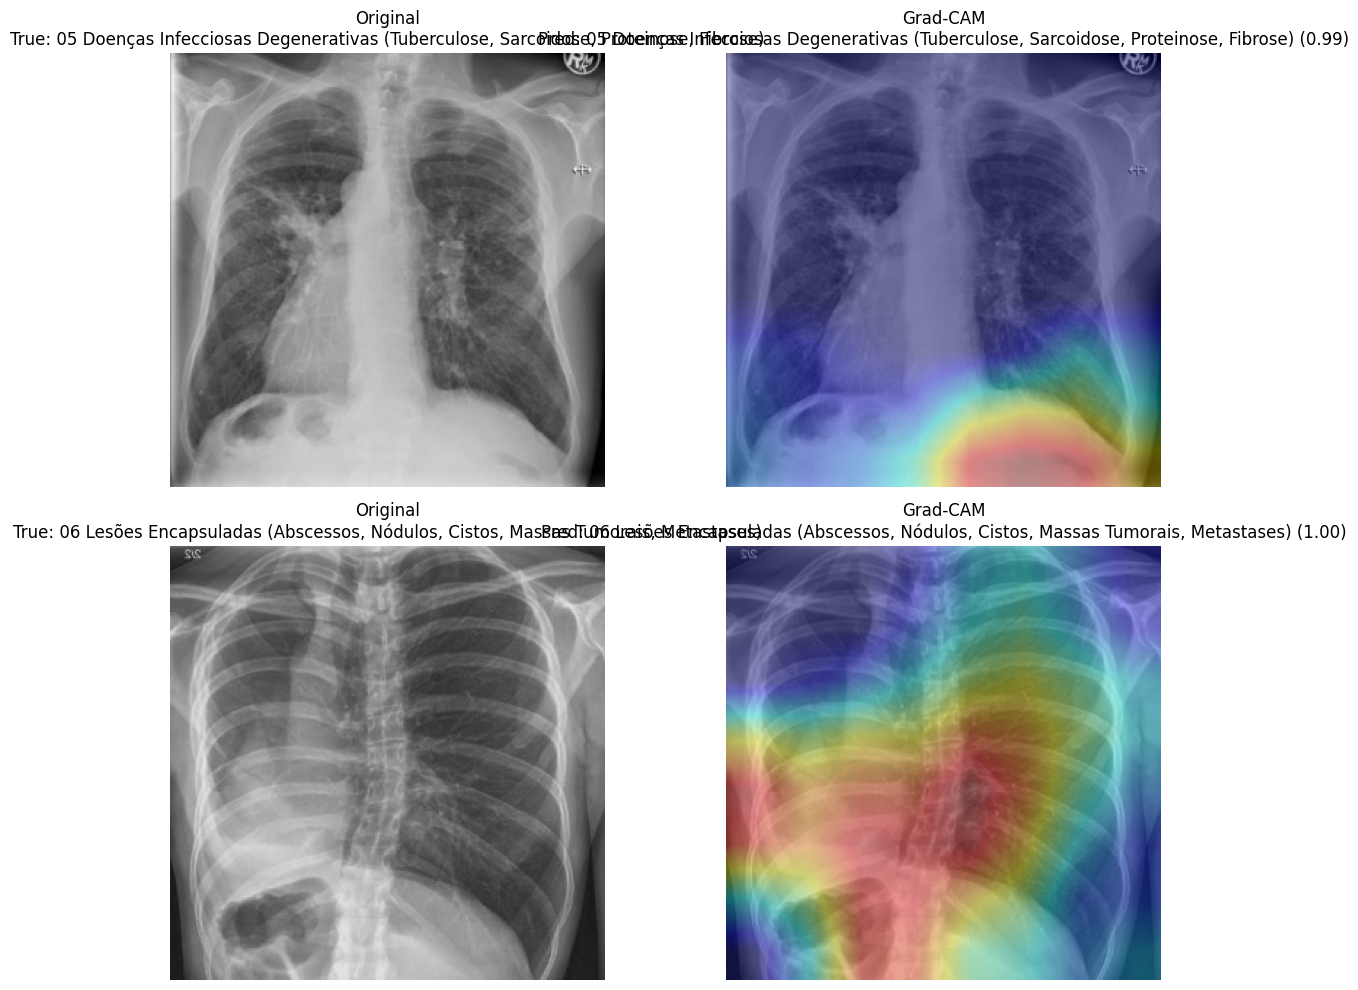

In [32]:
# Grad-CAM visualization on 2 random test images

gradcam_rows = test_df.sample(2, random_state=21).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i, row in gradcam_rows.iterrows():
    img_path = row["filepath"]
    true_label = row["label"]

    original_img, img_array = get_img_array_for_gradcam(img_path)

    heatmap, preds = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    pred_idx = int(np.argmax(preds[0]))
    pred_label = class_names[pred_idx]
    confidence = float(preds[0][pred_idx])

    gradcam_img = overlay_gradcam(original_img, heatmap)

    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(original_img, cmap="gray")
    plt.title(f"Original\nTrue: {true_label}")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(gradcam_img)
    plt.title(f"Grad-CAM\nPred: {pred_label} ({confidence:.2f})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# Optional: print labels for the Grad-CAM samples

for i, row in gradcam_rows.iterrows():
    _, img_array = get_img_array_for_gradcam(row["filepath"])
    preds = model.predict(img_array, verbose=0)
    pred_idx = int(np.argmax(preds[0]))

    print(
        f"Image {i+1} | True: {row['label']} | "
        f"Pred: {class_names[pred_idx]} | "
        f"Confidence: {preds[0][pred_idx]:.2f}"
    )


Image 1 | True: 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose) | Pred: 05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose) | Confidence: 0.99
Image 2 | True: 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases) | Pred: 06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases) | Confidence: 1.00
